In [1]:
import sys
import os

import pandas as pd
import numpy as np
import scanpy as sc

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype':42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
warnings.simplefilter("ignore")

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gnomad_df = pd.read_csv("./gnomad.v4.1.constraint_metrics.tsv",sep="\t")

In [3]:
gnomad_df_main = gnomad_df[gnomad_df["canonical"] & 
                           (gnomad_df["gene_id"].str.startswith("ENSG"))]

In [4]:
gnomad_df_main.columns

Index(['gene', 'gene_id', 'transcript', 'canonical', 'mane_select',
       'lof_hc_lc.obs', 'lof_hc_lc.exp', 'lof_hc_lc.possible', 'lof_hc_lc.oe',
       'lof_hc_lc.mu', 'lof_hc_lc.pLI', 'lof_hc_lc.pNull', 'lof_hc_lc.pRec',
       'lof.obs', 'lof.exp', 'lof.possible', 'lof.oe', 'lof.mu', 'lof.pLI',
       'lof.pNull', 'lof.pRec', 'lof.oe_ci.lower', 'lof.oe_ci.upper',
       'lof.oe_ci.upper_rank', 'lof.oe_ci.upper_bin_decile', 'lof.z_raw',
       'lof.z_score', 'mis.obs', 'mis.exp', 'mis.possible', 'mis.oe', 'mis.mu',
       'mis.oe_ci.lower', 'mis.oe_ci.upper', 'mis.z_raw', 'mis.z_score',
       'mis_pphen.obs', 'mis_pphen.exp', 'mis_pphen.possible', 'mis_pphen.oe',
       'syn.obs', 'syn.exp', 'syn.possible', 'syn.oe', 'syn.mu',
       'syn.oe_ci.lower', 'syn.oe_ci.upper', 'syn.z_raw', 'syn.z_score',
       'constraint_flags', 'level', 'transcript_type', 'chromosome',
       'cds_length', 'num_coding_exons'],
      dtype='object')

<Axes: xlabel='lof.oe_ci.upper', ylabel='Count'>

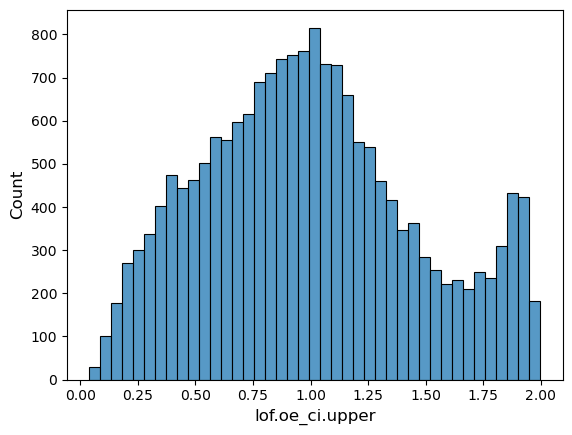

In [5]:
sns.histplot(gnomad_df_main["lof.oe_ci.upper"])

In [6]:
pval_df = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_052924/pval_transcript_full_v3.csv",
                          index_col=0)

In [7]:
pval_df_sig = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_052924/p_val_gRNA_sig_full_expressing_v3.csv",
                          index_col=0)

In [8]:
pval_df.head()

,distance_0,pval_0,distance_1,pval_1,distance_2,pval_2,distance_3,pval_3,distance_4,pval_4,...,distance_18,pval_18,distance_19,pval_19,pval_mean,pval_std,distance_mean,distance_std,pval_mean_log,distance_mean_log
ADNP2:P1P2,32.507812,0.000,23.557373,0.000,30.356812,0.000,25.965088,0.000,26.011475,0.000,...,33.399292,0.000,27.815430,0.000,0.00000,0.000000,28.853906,3.007461,5.000000,1.460205
AEBP1:P1P2,4.956543,0.230,5.575195,0.161,4.848511,0.226,5.487793,0.153,5.164062,0.213,...,4.756958,0.241,5.038086,0.223,0.19615,0.072972,5.258496,0.669756,0.707390,0.720862
AFF2:P1P2,1.993774,0.394,4.258179,0.026,1.979248,0.372,4.325073,0.033,3.380859,0.081,...,2.497925,0.193,2.444214,0.231,0.23940,0.172637,2.702185,0.907745,0.620858,0.431715
AFF3:P1P2,5.010254,0.070,2.576538,0.491,4.558716,0.103,2.826660,0.462,2.432861,0.585,...,4.685791,0.082,3.200439,0.323,0.26170,0.182374,3.702374,0.892977,0.582180,0.568480
AHCTF1:P1P2,21.561401,0.210,27.695435,0.105,20.286133,0.240,29.458618,0.085,25.785278,0.116,...,21.999512,0.193,23.208130,0.195,0.16875,0.056903,23.754736,3.228056,0.772730,1.375750


In [9]:
sig_transcript_list = pval_df_sig.index.to_numpy()

In [10]:
sig_transcript_list.shape

(211,)

In [11]:
sig_transcript_list

array(['ADNP2:P1P2', 'AHDC1:P1P2', 'ARID2:P1P2', 'ARID3A:P1P2',
       'ARID3B:P1P2', 'ARID4B:P1P2', 'ARNT:P1P2', 'AR:P1P2', 'ATMIN:P1P2',
       'ATXN7:ENST00000398590.3', 'BOLA3:P1P2', 'BPTF:P1P2', 'BRPF1:P1P2',
       'CAMTA2:P1P2', 'CDK2:P1P2', 'CDX1:P1P2', 'CHAMP1:P1P2',
       'CPEB1:ENST00000568128.1', 'CRAMP1L:P2', 'CREBBP:P1P2',
       'CSRNP2:P1P2', 'CTBP1:P1P2', 'DAXX:P2', 'DEK:P1P2', 'DLX2:P1P2',
       'DNAJC19', 'DNTTIP1:P1P2', 'DOT1L:P1P2', 'ELMSAN1:P2',
       'EOMES:P1P2', 'EP300:P1P2', 'ESRRA:P1P2', 'ETV3:P1P2', 'FOS:P1',
       'FOXC1:P1P2', 'FOXI3:P1P2', 'GATA4:P1P2', 'GATA6:P1P2',
       'GATAD1:P1P2', 'GLI3:P1P2', 'GTF2I:P1P2', 'HAND2:P1', 'HIF1A:P1P2',
       'HMG20A:P1P2', 'HOXB4:P1P2', 'ID2:P2', 'IKZF1:P1P2', 'IRF4:P1',
       'IRX2:P1P2', 'ISL1:P1', 'JUN:P1P2', 'KAT7:P1P2',
       'KCNIP3:ENST00000468529.1', 'KDM5B:P1P2', 'KDM5C:P1P2', 'KLF10:P1',
       'KMT2A:P1P2', 'LEF1:P2', 'LHX2:P1P2', 'LZTR1:P1P2', 'LZTS1:P1P2',
       'MAFB:P1P2', 'MAP3K7:P1P2', 'MAPK8

In [12]:
gRNA_level_stat = pd.read_csv("./gRNA_fit_stat.csv",index_col=0)

In [13]:
gRNA_level_stat.head()

,num_valid_gRNA,pearson_r,expression_range,exp_0,exp_1,lin_0,lin_1,err_exp,err_lin,err_exp/lin
AFF4,6.0,-0.476689,0.864626,77896.940357,0.000289,-17.753748,4.181333,330.995659,2.449371e+10,1.351350e-08
AHDC1,5.0,-0.165595,0.676786,343864.374018,0.000322,-72.048041,26.071973,7091.103635,2.266223e+11,3.129040e-08
ARID2,4.0,0.477407,0.753383,112016.494852,0.000425,-23.538736,18.625578,1665.891144,2.522062e+10,6.605275e-08
ARID3B,6.0,0.776278,0.571844,90678.581872,0.000558,18.396328,31.053645,4624.930766,7.651423e+09,6.044537e-07
ARID4B,5.0,-0.581141,0.347847,80950.979489,0.000607,-48.135791,0.703847,329.114896,1.412622e+10,2.329815e-08


In [14]:
annotation_file = "/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_additonal/full_annotation_df2.csv"

In [15]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,guide_chr,guide_start,guide_end,protospacer_target,transcript_target,closest_gene,closest_dist
0,chr16,70289419,70289438,AARS_B,AARS,AARS1,78
1,chr16,70289397,70289416,AARS_C,AARS,AARS1,100
2,chr16,70289477,70289496,AARS_main,AARS,AARS1,20
3,chr17,36948966,36948985,AATF_-_35306286.23-P1P2-1,AATF:P1P2,AATF,21
4,chr17,36949026,36949045,AATF_-_35306286.23-P1P2-2,AATF:P1P2,AATF,81


In [16]:
#Manual gene name change for signigicant hits
annotation_df["closest_gene"] = \
    annotation_df["closest_gene"].str.replace("CENPS-CORT","CENPS")
# In gnomad, they used MIDEAS instead of ELMSAN1
# annotation_df["closest_gene"] = \
#     annotation_df["closest_gene"].str.replace("MIDEAS","ELMSAN1")

In [17]:
transcript_gene_dict = {}
total_transcript = np.unique(annotation_df["transcript_target"])

for transcript_tmp in total_transcript:
    gene_name_tmp = annotation_df[annotation_df["transcript_target"]==transcript_tmp]["closest_gene"].values[0]
    gene_name_from_transcript = transcript_tmp.split(":")[0]
    if gene_name_tmp != gene_name_from_transcript:
        print(transcript_tmp,gene_name_tmp,gene_name_from_transcript)
    transcript_gene_dict[transcript_tmp] = gene_name_tmp

AARS AARS1 AARS
APITD1-CORT:P1P2 CENPS APITD1-CORT
APITD1:P1P2 CENPS APITD1
C11orf95:P1P2 ZFTA C11orf95
C1orf85:P1 GLMP C1orf85
C1orf85:P2 SMG5 C1orf85
CCDC79:P1P2 TERB1 CCDC79
CD29 ITGB1 CD29
CENPBD1:P1P2 CENPBD1P CENPBD1
CRAMP1L:P1 CRAMP1 CRAMP1L
CRAMP1L:P2 CRAMP1 CRAMP1L
ELMSAN1:P1 MIDEAS ELMSAN1
ELMSAN1:P2 MIDEAS ELMSAN1
HKR1:P1 ZNF875 HKR1
HKR1:P2 ZNF875 HKR1
KIAA2018:P1P2 USF3 KIAA2018
MARS:P1P2 MARS1 MARS
MEF2BNB-MEF2B:P1P2 BORCS8-MEF2B MEF2BNB-MEF2B
MTERF:P1P2 MTERF1 MTERF
MTERFD1:P1P2 MTERF3 MTERFD1
MTERFD2:P1P2 MTERF4 MTERFD2
MTERFD3:P1P2 MTERF2 MTERFD3
NGFRAP1 BEX3 NGFRAP1
NOV:P1P2 CCN3 NOV
OR8U8 OR8U1 OR8U8
PRKRIR:P1P2 THAP12 PRKRIR
SCAND3:P1P2 ZBED9 SCAND3
SCXA:ENST00000340695.2 SCX SCXA
SCXB:ENST00000340210.1 SCX SCXB
STRA13:P1P2 CENPX STRA13
T:P1P2 TBXT T
TAZ:P1P2 TAFAZZIN TAZ
TCEB1:P1P2 ELOC TCEB1
TCEB2:P1P2 ELOB TCEB2
TCEB3:P1P2 ELOA TCEB3
WHSC1:P1P2 NSD2 WHSC1
ZCCHC11:P1P2 TUT4 ZCCHC11
ZCCHC6:P1P2 TUT7 ZCCHC6
ZFYVE20:P1P2 RBSN ZFYVE20
ZNF645:P1P2 CBLL2 ZNF645
ZNF720:P

In [18]:
total_gene_list = [transcript_gene_dict[x] for x in total_transcript]
sig_gene_list = [transcript_gene_dict[x] for x in sig_transcript_list if x in transcript_gene_dict.keys()]

In [19]:
sig_gene_list = np.unique(sig_gene_list)

In [20]:
sig_gene_list[~np.isin(sig_gene_list,gnomad_df_main["gene"])]

array(['AR', 'KDM5C', 'NONO', 'ZNF41'], dtype='<U8')

In [21]:
gnomad_df_main_test = gnomad_df_main[np.isin(gnomad_df_main["gene"],total_gene_list)]

In [22]:
gnomad_df_main_test["is_sig"] = np.isin(gnomad_df_main_test["gene"],sig_gene_list)

In [23]:
corr_test_genes = gRNA_level_stat[gRNA_level_stat["pearson_r"]<-0.5].index.to_numpy()

In [24]:
corr_test_genes

array(['ARID4B', 'CENPS', 'CHAMP1', 'GATA4', 'HMG20A', 'KCNIP3', 'KLF12',
       'LEF1', 'LZTR1', 'NOTCH2', 'PCGF2', 'PCGF6', 'RB1CC1', 'RBPJ',
       'RCOR2', 'RNF2', 'SOX4', 'TADA2B', 'TBX5', 'THAP2', 'YWHAE',
       'ZEB1', 'ZNF41', 'ZNF608', 'ZSCAN20'], dtype=object)

In [54]:
new_columns_name = [x.replace(".","_") for x in gnomad_df_main_test.columns]

In [55]:
gnomad_df_main_test.columns = new_columns_name
print(gnomad_df_main_test.columns)

Index(['gene', 'gene_id', 'transcript', 'canonical', 'mane_select',
       'lof_hc_lc_obs', 'lof_hc_lc_exp', 'lof_hc_lc_possible', 'lof_hc_lc_oe',
       'lof_hc_lc_mu', 'lof_hc_lc_pLI', 'lof_hc_lc_pNull', 'lof_hc_lc_pRec',
       'lof_obs', 'lof_exp', 'lof_possible', 'lof_oe', 'lof_mu', 'lof_pLI',
       'lof_pNull', 'lof_pRec', 'lof_oe_ci_lower', 'lof_oe_ci_upper',
       'lof_oe_ci_upper_rank', 'lof_oe_ci_upper_bin_decile', 'lof_z_raw',
       'lof_z_score', 'mis_obs', 'mis_exp', 'mis_possible', 'mis_oe', 'mis_mu',
       'mis_oe_ci_lower', 'mis_oe_ci_upper', 'mis_z_raw', 'mis_z_score',
       'mis_pphen_obs', 'mis_pphen_exp', 'mis_pphen_possible', 'mis_pphen_oe',
       'syn_obs', 'syn_exp', 'syn_possible', 'syn_oe', 'syn_mu',
       'syn_oe_ci_lower', 'syn_oe_ci_upper', 'syn_z_raw', 'syn_z_score',
       'constraint_flags', 'level', 'transcript_type', 'chromosome',
       'cds_length', 'num_coding_exons', 'is_sig'],
      dtype='object')


In [56]:
gnomad_df_main_test_sig = gnomad_df_main_test[
        np.isin(gnomad_df_main_test["gene"],corr_test_genes)]

In [57]:
gnomad_df_main_test_sig["err_ratio"] = gnomad_df_main_test_sig["gene"].apply(
                                lambda x:gRNA_level_stat.at[x,"err_exp/lin"])
gnomad_df_main_test_sig["err_ratio_log10"] = np.log10(gnomad_df_main_test_sig["err_ratio"])

In [58]:
from scipy.stats import anderson_ksamp
result = anderson_ksamp([gnomad_df_main_test[gnomad_df_main_test["is_sig"]]["lof_oe_ci_upper"].values,
                         gnomad_df_main_test[~gnomad_df_main_test["is_sig"]]["lof_oe_ci_upper"].values])

print(gnomad_df_main_test[gnomad_df_main_test["is_sig"]].shape)
print(gnomad_df_main_test[~gnomad_df_main_test["is_sig"]].shape)
print(result.pvalue)

(205, 56)
(1807, 56)
0.001


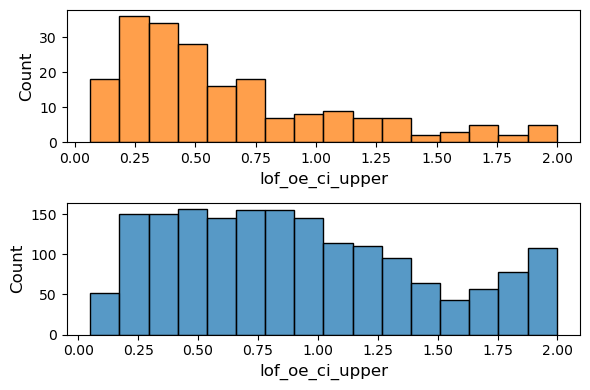

In [59]:
fig,ax = plt.subplots(2,1,figsize=(6,4))
sns.histplot(data=gnomad_df_main_test[gnomad_df_main_test["is_sig"]],
             x="lof_oe_ci_upper",bins=16,ax=ax[0],color=sns.color_palette()[1])
sns.histplot(data=gnomad_df_main_test[~gnomad_df_main_test["is_sig"]],
             x="lof_oe_ci_upper",bins=16,ax=ax[1])
plt.tight_layout()

plt.savefig("./loeuf_histgram.pdf")

In [60]:
gnomad_df_main_test_sig["lof_pLI"]

12740      1.000000e+00
33024      3.464700e-06
34936      1.000000e+00
69917      9.912200e-01
79160      7.798800e-01
88660      1.796400e-09
91224      9.988700e-01
94590      9.964100e-01
99205     4.991500e-132
118255     1.000000e+00
127428     9.968700e-01
127454     1.191000e-04
146989     1.000000e+00
147960     1.000000e+00
148260     8.228100e-01
151853     9.999300e-01
169815     7.891700e-01
177392     4.553900e-02
179353     1.000000e+00
181781     5.660700e-05
201155     9.999900e-01
202786     1.000000e+00
208279     1.000000e+00
210327     8.342300e-01
Name: lof_pLI, dtype: float64

<Axes: xlabel='lof_pLI', ylabel='err_ratio_log10'>

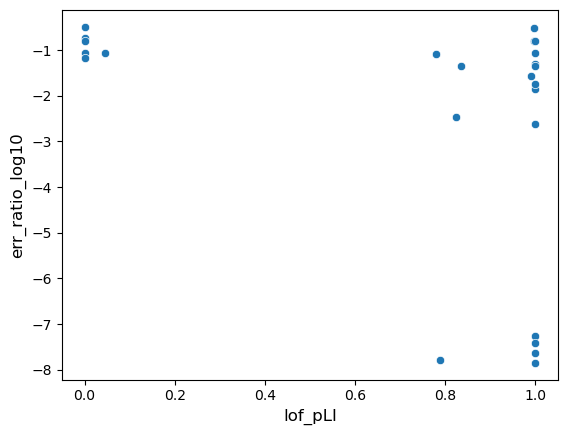

In [61]:
sns.scatterplot(data=gnomad_df_main_test_sig,x="lof_pLI",y="err_ratio_log10")

In [62]:
gnomad_df_main_test_sig.head()

,gene,gene_id,transcript,canonical,mane_select,lof_hc_lc_obs,lof_hc_lc_exp,lof_hc_lc_possible,lof_hc_lc_oe,lof_hc_lc_mu,...,syn_z_score,constraint_flags,level,transcript_type,chromosome,cds_length,num_coding_exons,is_sig,err_ratio,err_ratio_log10
12740,ARID4B,ENSG00000054267,ENST00000264183,True,True,9.0,89.106,537.0,0.101000,9.751700e-07,...,0.50076,[],2.0,protein_coding,chr1,3936.0,23.0,True,2.329815e-08,-7.632678
33024,CENPS,ENSG00000175279,ENST00000309048,True,True,23.0,21.312,102.0,1.079200,4.347700e-07,...,0.42109,[],2.0,protein_coding,chr1,414.0,5.0,True,3.229802e-01,-0.490824
34936,CHAMP1,ENSG00000198824,ENST00000361283,True,True,4.0,57.068,341.0,0.070092,3.132000e-07,...,-0.18076,[],2.0,protein_coding,chr13,2436.0,1.0,True,8.643301e-02,-1.063320
69917,GATA4,ENSG00000136574,ENST00000532059,True,True,7.0,28.065,129.0,0.249420,5.564700e-07,...,-4.37720,"[""outlier_syn""]",2.0,protein_coding,chr8,1329.0,6.0,True,2.674549e-02,-1.572750
79160,HMG20A,ENSG00000140382,ENST00000336216,True,True,12.0,34.575,161.0,0.347080,4.872400e-07,...,0.83459,[],2.0,protein_coding,chr15,1041.0,8.0,True,8.359597e-02,-1.077815


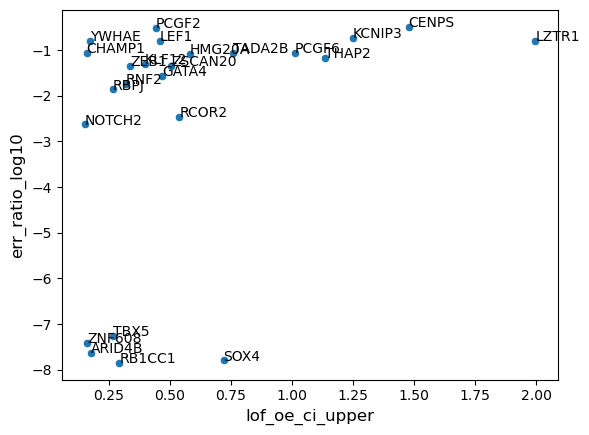

In [63]:
sns.scatterplot(data=gnomad_df_main_test_sig,x="lof_oe_ci_upper",y="err_ratio_log10")
for row in gnomad_df_main_test_sig.itertuples():
    plt.annotate(row.gene, (row.lof_oe_ci_upper, row.err_ratio_log10))
plt.savefig("curvefit_loeuf_plot.pdf")

In [32]:
pearsonr(gnomad_df_main_test_sig["err_ratio_log10"],
         gnomad_df_main_test_sig["lof.pLI"]
        )

PearsonRResult(statistic=-0.3631664674602303, pvalue=0.08110877252282012)

In [33]:
gnomad_df_main_test_sig.sort_values("err_ratio_log10").loc[:,["gene","lof.oe_ci.upper","err_ratio_log10"]]

,gene,lof.oe_ci.upper,err_ratio_log10
146989,RB1CC1,0.293,-7.844771
169815,SOX4,0.720,-7.795937
12740,ARID4B,0.176,-7.632678
208279,ZNF608,0.161,-7.421881
179353,TBX5,0.267,-7.261912
118255,NOTCH2,0.151,-2.630616
148260,RCOR2,0.539,-2.459805
147960,RBPJ,0.267,-1.863973
151853,RNF2,0.321,-1.750323
69917,GATA4,0.468,-1.572750


In [34]:
gRNA_level_stat["err_exp/lin"].sort_values()

ZNF844    5.476571e-09
TBX20     7.800761e-09
ZNF454    8.780185e-09
TIGD1     9.179313e-09
LHX2      9.372021e-09
              ...     
KDM5B     3.197051e-01
CENPS     3.229802e-01
OVOL2     3.670834e-01
ETV3      3.860598e-01
MAP3K7    3.915857e-01
Name: err_exp/lin, Length: 109, dtype: float64

In [35]:
gRNA_level_stat["pearson_r"].sort_values().head(20)

RCOR2     -0.920321
NOTCH2    -0.918190
RB1CC1    -0.881728
GATA4     -0.870592
ZSCAN20   -0.854231
KLF12     -0.849126
TBX5      -0.833288
ZNF608    -0.809944
RBPJ      -0.787697
PCGF6     -0.752105
ZNF41     -0.751569
TADA2B    -0.723717
THAP2     -0.717427
LEF1      -0.703549
CHAMP1    -0.696732
SOX4      -0.696134
RNF2      -0.679264
ZEB1      -0.657211
KCNIP3    -0.650698
YWHAE     -0.612012
Name: pearson_r, dtype: float64